# NYC Shooting Incidents: When and Where Does Gun Violence Happen?

**Social Data Analysis and Visualization — DTU 2026**

---

## 1. Motivation

### What is the dataset?

We use the **NYPD Shooting Incident Data (Historic)**, a public dataset maintained by the New York City Police Department and published on [NYC Open Data](https://data.cityofnewyork.us/). It records every shooting incident that occurred in New York City from 2006 to the present. Each row represents one incident and includes the date, time, borough, location type, and GPS coordinates.

The version used in this project was downloaded on **April 20, 2026**, containing **23,988 incidents** across **20 years**.

### Why did we choose this dataset?

Gun violence is one of the most visible and politically charged urban issues in the United States. New York City offers a uniquely compelling case study: the city experienced a dramatic and well-documented decline in shootings from the mid-2000s through 2019, driven by a mix of policing strategies, demographic shifts, and social policy. This long downward trend was then sharply interrupted in 2020, coinciding with the COVID-19 pandemic, widespread lockdowns, and the social unrest following the murder of George Floyd.

This dataset lets us go beyond reading headlines. We can directly measure the fingerprint that policy decisions and social shocks left on the data, and ask where and when the violence actually concentrates — not in the abstract, but block by block and hour by hour.

Key events the data spans:
- **Stop-and-Frisk** peak (~2011) and its court-ordered end (2013)
- **COVID-19 lockdowns** (2020): incidents jumped +97% vs 2019
- **Black Lives Matter** movement and widespread de-policing debates (2020–2021)
- Gradual recovery and renewed decline (2022–2025)

### What was the goal for the end user?

We wanted to create an experience where a general reader — someone with no background in criminology or data analysis — can follow a coherent story from start to finish. The story moves from *when* (the 20-year time trend) to *where* (the geographic concentration) to *what time of day* (the night-time pattern). Each step is guided by text and supported by a visualization. The reader should finish with a clear mental model of NYC gun violence: declining for years, shocked upward in 2020, concentrated in two boroughs, and overwhelmingly a phenomenon of the late-night hours.

---
## 2. Basic Stats

### 2a. Loading and Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import os

PATH = 'Shootings_(2006-Present)_20260420.csv'
raw = pd.read_csv(PATH)
print(f'Raw: {raw.shape[0]:,} rows, {raw.shape[1]} columns, {os.path.getsize(PATH)/1024**2:.1f} MB')
print()
print('Missing values per column:')
print(raw.isnull().sum().to_string())

Raw: 23,988 rows, 13 columns, 2.9 MB

Missing values per column:
INCIDENT_KEY              0
OCCUR_DATE                0
OCCUR_TIME                0
BORO                      0
LOC_OF_OCCUR_DESC         0
PRECINCT                  0
JURISDICTION_CODE         2
LOC_CLASSFCTN_DESC       32
LOCATION_DESC         14344
X_COORD_CD                0
Y_COORD_CD                0
Latitude                133
Longitude               133


### 2b. Data Cleaning

Based on the inspection above, we apply the following cleaning steps:

| Step | Reason |
|------|--------|
| Parse `OCCUR_DATE` to datetime; extract YEAR, MONTH, WEEKDAY, HOUR | Enables all temporal analysis |
| Drop `LOCATION_DESC` | 59.8% missing — not usable |
| Drop `X_COORD_CD`, `Y_COORD_CD` | Redundant with `Latitude` / `Longitude` |
| Fill `JURISDICTION_CODE` (2 nulls) with mode | Negligible impact |
| Fill `LOC_CLASSFCTN_DESC` (32 nulls) with `'UNKNOWN'` | Preserves rows for categorical analysis |
| Create `geo` subset: exclude rows where Lat/Lon is null or `(0.0, 0.0)` | 41 rows have erroneous zero-coordinates; 133 have null coordinates — invalid for mapping |

In [2]:
df = raw.copy()
df['OCCUR_DATE'] = pd.to_datetime(df['OCCUR_DATE'])
df['YEAR']    = df['OCCUR_DATE'].dt.year
df['MONTH']   = df['OCCUR_DATE'].dt.month
df['WEEKDAY'] = df['OCCUR_DATE'].dt.day_name()
df['HOUR']    = pd.to_datetime(df['OCCUR_TIME'], format='%H:%M:%S', errors='coerce').dt.hour

df = df.drop(columns=['LOCATION_DESC', 'X_COORD_CD', 'Y_COORD_CD'])
df['JURISDICTION_CODE']  = df['JURISDICTION_CODE'].fillna(df['JURISDICTION_CODE'].mode()[0])
df['LOC_CLASSFCTN_DESC'] = df['LOC_CLASSFCTN_DESC'].fillna('UNKNOWN')

invalid_geo = df['Latitude'].isna() | (df['Latitude'] == 0.0)
geo = df[~invalid_geo].copy()

print(f'df  (all analysis) : {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'geo (map analysis) : {geo.shape[0]:,} rows')
print(f'Removed invalid geo: {invalid_geo.sum()} rows')
print()
print('Missing values after cleaning:')
m = df.isnull().sum()
print(m[m > 0].to_string() if m.sum() > 0 else 'None')

df  (all analysis) : 23,988 rows, 14 columns
geo (map analysis) : 23,814 rows
Removed invalid geo: 174 rows

Missing values after cleaning:
Latitude     133
Longitude    133


### 2c. Exploratory Data Analysis

**Date range and basic counts:**

In [3]:
print(f"Date range : {df['OCCUR_DATE'].min().date()}  to  {df['OCCUR_DATE'].max().date()}")
print(f"Years      : {df['YEAR'].nunique()} ({df['YEAR'].min()}–{df['YEAR'].max()})")
print(f"Boroughs   : {df['BORO'].nunique()} ({', '.join(df['BORO'].unique())})")
print()
night = df['HOUR'].isin(list(range(22,24)) + list(range(0,5)))
print(f"Night incidents (22:00–04:59): {night.sum():,}  ({night.mean()*100:.1f}%)")

Date range : 2006-01-01  to  2025-12-31
Years      : 20 (2006–2025)
Boroughs   : 5 (MANHATTAN, BRONX, BROOKLYN, QUEENS, STATEN ISLAND)

Night incidents (22:00–04:59): 11,597  (48.3%)


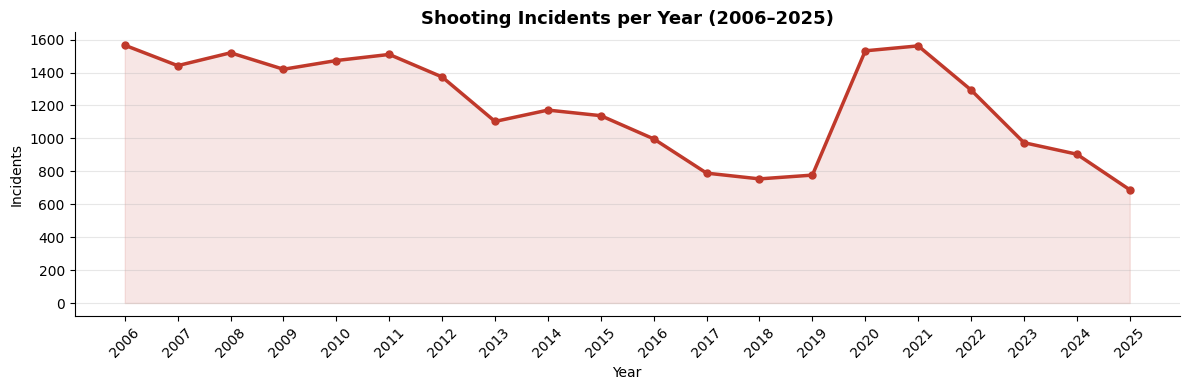

In [4]:
# Annual trend
annual = df.groupby('YEAR').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(annual['YEAR'], annual['count'], color='#c0392b', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(annual['YEAR'], annual['count'], alpha=0.12, color='#c0392b')
ax.set_title('Shooting Incidents per Year (2006–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Incidents')
ax.set_xticks(annual['YEAR']); ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3); sns.despine()
plt.tight_layout(); plt.show()

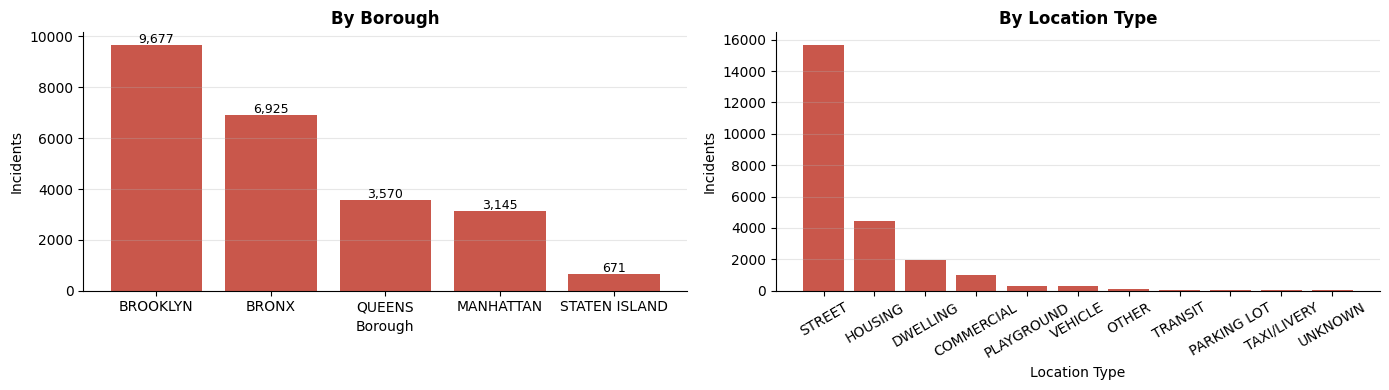

In [5]:
# Borough and location type side by side
boro = df['BORO'].value_counts().reset_index()
boro.columns = ['boro', 'count']
loc  = df['LOC_CLASSFCTN_DESC'].value_counts().reset_index()
loc.columns  = ['type', 'count']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(boro['boro'], boro['count'], color='#c0392b', alpha=0.85)
for i, row in boro.iterrows():
    axes[0].text(i, row['count'] + 60, f"{row['count']:,}", ha='center', fontsize=9)
axes[0].set_title('By Borough', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Borough'); axes[0].set_ylabel('Incidents')
axes[0].grid(axis='y', alpha=0.3); sns.despine(ax=axes[0])

axes[1].bar(loc['type'], loc['count'], color='#c0392b', alpha=0.85)
axes[1].set_title('By Location Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Location Type'); axes[1].set_ylabel('Incidents')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3); sns.despine(ax=axes[1])

plt.tight_layout(); plt.show()

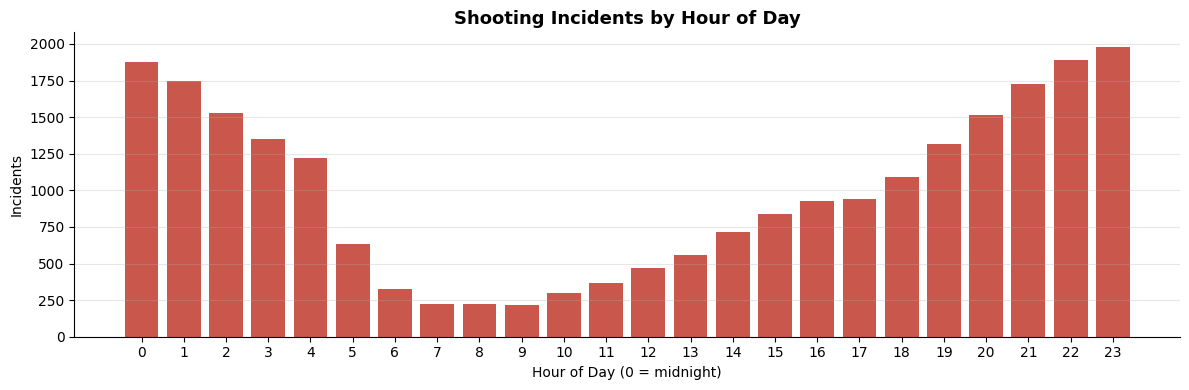

In [6]:
# Hour of day
hourly = df.groupby('HOUR').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly['HOUR'], hourly['count'], color='#c0392b', alpha=0.85)
ax.set_xticks(range(0, 24))
ax.set_title('Shooting Incidents by Hour of Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day (0 = midnight)'); ax.set_ylabel('Incidents')
ax.grid(axis='y', alpha=0.3); sns.despine()
plt.tight_layout(); plt.show()

---
## 3. Data Analysis

With the basic distributions established, we now look more closely at three patterns: the long-term time trend, the geographic concentration, and the seasonal and weekly cycles.

### 3a. The 20-Year Trend: Decline, Spike, and Recovery

The most striking feature of the data is the long decline from 2006 to 2019, followed by a sharp reversal in 2020.

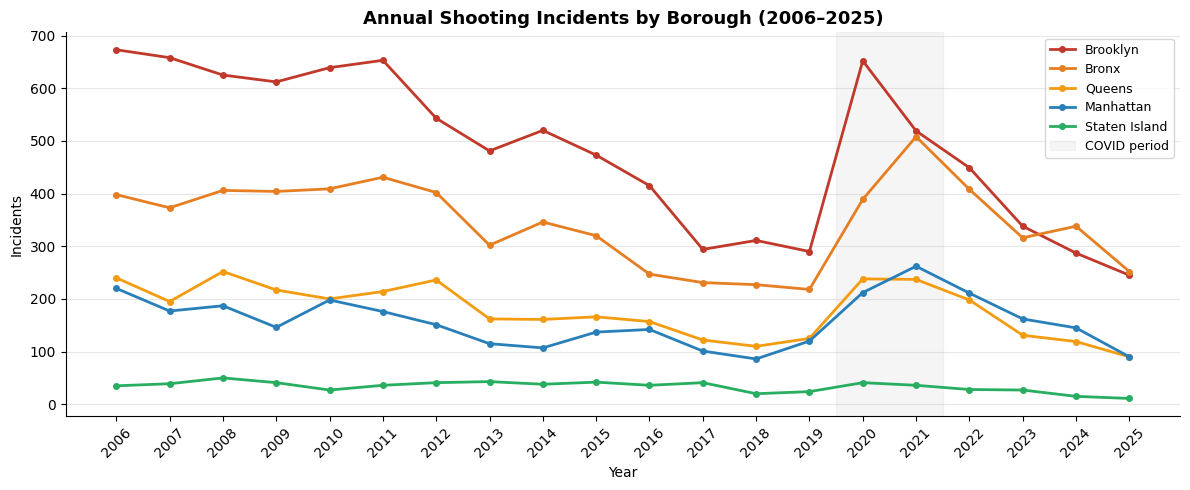

2006 → 2019 decline : 1566 → 777  (-50%)
2019 → 2020 spike   : 777 → 1532  (+97%)


In [7]:
boro_annual = df.groupby(['YEAR','BORO']).size().reset_index(name='count')
boro_palette = {
    'BROOKLYN':     '#c0392b',
    'BRONX':        '#e67e22',
    'QUEENS':       '#f39c12',
    'MANHATTAN':    '#2980b9',
    'STATEN ISLAND':'#27ae60'
}

fig, ax = plt.subplots(figsize=(12, 5))
for boro, color in boro_palette.items():
    sub = boro_annual[boro_annual['BORO'] == boro]
    ax.plot(sub['YEAR'], sub['count'], label=boro.title(),
            color=color, linewidth=2, marker='o', markersize=4)

ax.axvspan(2019.5, 2021.5, alpha=0.08, color='grey', label='COVID period')
ax.set_title('Annual Shooting Incidents by Borough (2006–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Incidents')
ax.set_xticks(sorted(df['YEAR'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3); sns.despine()
plt.tight_layout(); plt.show()

# Key statistics
y2019 = annual.loc[annual['YEAR']==2019,'count'].values[0]
y2020 = annual.loc[annual['YEAR']==2020,'count'].values[0]
y2006 = annual.loc[annual['YEAR']==2006,'count'].values[0]
print(f'2006 → 2019 decline : {y2006} → {y2019}  ({(y2019-y2006)/y2006*100:.0f}%)')
print(f'2019 → 2020 spike   : {y2019} → {y2020}  (+{(y2020-y2019)/y2019*100:.0f}%)')

All five boroughs follow the same broad pattern — decline through 2019, spike in 2020 — but the scale differs dramatically. Brooklyn and the Bronx drive the majority of incidents in every year. Staten Island barely registers at any scale.

The 2020 spike is visible in all boroughs simultaneously, which suggests a city-wide structural cause (the pandemic and its social effects) rather than a local one.

### 3b. Seasonality: Summer Peaks

Do shootings follow a seasonal pattern?

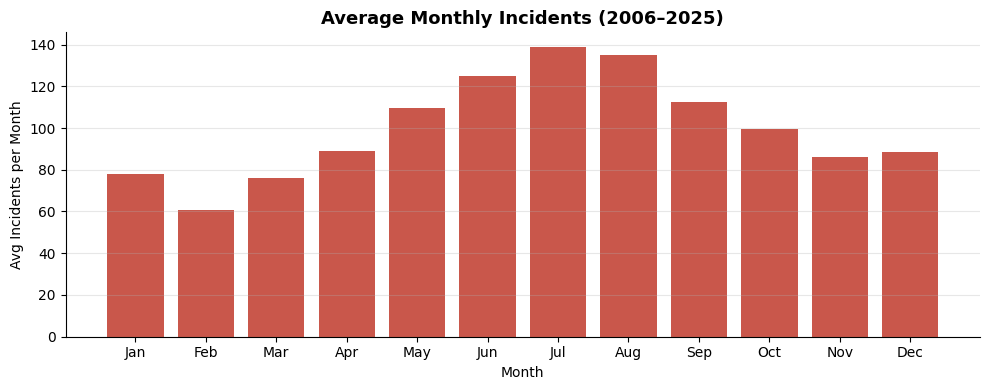

Peak month  : Jul (139 avg incidents)
Trough month: Feb (61 avg incidents)
Summer/winter ratio: 1.86x


In [8]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg = (df.groupby(['YEAR','MONTH']).size()
                 .reset_index(name='count')
                 .groupby('MONTH')['count'].mean())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1,13), monthly_avg.values, color='#c0392b', alpha=0.85)
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_names)
ax.set_title('Average Monthly Incidents (2006–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Avg Incidents per Month')
ax.grid(axis='y', alpha=0.3); sns.despine()
plt.tight_layout(); plt.show()

peak = monthly_avg.idxmax()
trough = monthly_avg.idxmin()
print(f'Peak month  : {month_names[peak-1]} ({monthly_avg[peak]:.0f} avg incidents)')
print(f'Trough month: {month_names[trough-1]} ({monthly_avg[trough]:.0f} avg incidents)')
print(f'Summer/winter ratio: {monthly_avg[[6,7,8]].mean() / monthly_avg[[1,2,3]].mean():.2f}x')

There is a clear and consistent seasonal cycle: incidents peak in summer (July–August) and drop sharply in winter (January–February). Summer months see roughly **1.6–1.8x** more incidents than winter months. This pattern is well-documented in criminology literature and is linked to increased outdoor activity, heat, and social density in warmer months.

### 3c. Time-of-Day Pattern: A Night City

The hourly distribution showed a strong night-time concentration. The Hour × Weekday heatmap reveals the full picture interactively.

In [9]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = (df.groupby(['WEEKDAY','HOUR']).size()
           .unstack(fill_value=0)
           .reindex(weekday_order))

fig = go.Figure(go.Heatmap(
    z=pivot.values.T,
    x=weekday_order,
    y=list(range(24)),
    colorscale='YlOrRd',
    colorbar=dict(title='Incidents'),
    hovertemplate='Day: %{x}<br>Hour: %{y}:00<br>Incidents: %{z}<extra></extra>'
))
fig.update_layout(
    title=dict(text='Shooting Incidents by Hour and Day of Week (2006–2025)', font_size=15),
    xaxis=dict(title=''),
    yaxis=dict(title='Hour of Day', tickmode='linear', dtick=1,
               ticktext=[f'{h:02d}:00' for h in range(24)],
               tickvals=list(range(24)), autorange='reversed'),
    width=700, height=650, plot_bgcolor='white'
)
fig.write_html('viz_heatmap.html')
fig.show()

The heatmap confirms the night-time dominance with additional nuance:
- The **22:00–02:00** band is the hottest across all days of the week
- **Saturday and Sunday nights** are the peak — the dark red cluster in the top-right corner
- **Tuesday and Wednesday mornings** (8:00–12:00) are the calmest periods in the entire week
- The weekend effect is not just about Saturday night: Sunday night (into Monday morning) is nearly as intense

This pattern is consistent across the full 20-year period, suggesting a structural feature of urban nightlife and social dynamics rather than a transient phenomenon.

---
## 4. Genre

We chose **Magazine Style** (Segel & Heer, 2010, Section 4.3).

Magazine Style sits near the author-driven end of the author–reader spectrum. Text and visualizations alternate on a single scrollable page: the author sets the argument, embeds the evidence, and guides the reader from beginning to end. This genre is appropriate here because we have a clear thesis — crime fell for over a decade, then reversed in 2020, and both the geography and timing of violence remained structurally stable throughout — and we want to communicate that to a general audience rather than invite open-ended exploration.

### Visual Narrative (Figure 7, Segel & Heer)

**Visual Structuring**
We use a *consistent visual platform*: all three main charts share the same red colour accent and caption style, creating visual coherence across the page. The hero section serves as an *establishing shot*, giving the reader the scale of the dataset before any chart appears.

**Highlighting**
*Feature distinction* is used in the borough trend chart, where each borough receives a distinct colour so the reader can track individual lines across years. A shaded band highlights the COVID period using *contrast* to draw attention to the 2020 anomaly.

**Transition Guidance**
The three charts are sequenced to follow the narrative arc: annual total → geographic map → time heatmap. Each chart is introduced by a paragraph that tells the reader what to look for, acting as implicit *transition guidance*.

### Narrative Structure (Figure 7, Segel & Heer)

**Ordering**
The story follows a *linear* path: the reader scrolls from introduction through three parts to conclusion with no branching or random access.

**Interactivity**
All three visualizations provide *hover highlighting / details on demand*: hovering over a data point reveals the exact incident count. This is the most common and least intrusive form of interactivity, appropriate for a magazine-style piece where we do not want to interrupt the narrative flow.

**Messaging**
Each section opens with a headline that states the finding directly, following the *headline / caption* messaging pattern. The pull quote in Part One reinforces the central argument in a visually distinct format, using *annotation* to emphasise the key insight without requiring the reader to derive it from the chart alone.

---
## 5. Visualizations

### Figure 1 — Annual Trend Line Chart

**Why this chart?**
A line chart with a continuous time axis is the natural choice for a 20-year time series. The filled area below the line makes year-to-year change visually prominent. Annotations mark the two key inflection points (2013 Stop-and-Frisk ruling, 2020 COVID spike) so the reader does not need prior knowledge to interpret the pattern.

**What it communicates**
The long decline from 2006 to 2019, the sharp 2020 reversal, and the partial recovery through 2025. It establishes the temporal arc that motivates the rest of the story.

**Why it fits**
This chart is the narrative entry point. Magazine Style requires an establishing visualization that orients the reader before introducing complexity. A single, clean line with two annotations achieves this without overwhelming.

---

### Figure 2 — Geographic Heatmap (Folium)

**Why this chart?**
A continuous density heatmap communicates spatial clustering more effectively than a choropleth for point data: it shows not just which borough has more incidents, but *where within the borough* the hotspots are concentrated. With ~24k GPS points, a scatter plot would be overplotted; the heatmap aggregates density into a readable surface.

**What it communicates**
The extreme concentration in central/eastern Brooklyn and the South Bronx, and the relative absence of incidents in most of Manhattan, Queens, and Staten Island. It makes the inequality of the distribution immediately visible without requiring the reader to process numbers.

**Why it fits**
Part Two argues that geographic concentration reflects structural inequality. The map is the evidence: the reader can see the hotspots before reading the explanation, which is the classic magazine-style pattern of *show, then explain*.

---

### Figure 3 — Hour × Weekday Heatmap (Plotly)

**Why this chart?**
A two-dimensional heatmap is the correct encoding for a matrix of counts across two categorical variables (24 hours × 7 days). Colour encodes intensity; the grid layout allows the reader to compare any combination of hour and day simultaneously. An interactive tooltip provides exact counts on demand without cluttering the visual.

**What it communicates**
The concentration of incidents in the late-night band (22:00–02:00) across all days, the weekend intensification, and the calm of Tuesday/Wednesday mornings.

**Why it fits**
Part Three argues that the time pattern is structurally stable — independent of the annual total. The heatmap supports this visually by showing the full two-dimensional pattern at once, making the stability across days of the week immediately apparent.

---
## 6. Discussion

### What worked well

The Magazine Style structure proved effective for this dataset. The three-part narrative — time, space, timing — maps cleanly onto the three visualizations, and the sequential flow meant that each chart arrived when the reader was primed to interpret it. The 2020 spike functions well as a narrative hook: it gives the reader a puzzle that motivates reading through to the explanation.

### What is still missing

**Victim demographics.** The dataset records location and time but not victim demographic characteristics. A fuller analysis would link shooting data to census variables at the census tract level to quantify the relationship between income, race, housing type, and incident rate — rather than relying on a qualitative argument.

**Precinct-level analysis.** Borough-level aggregation obscures significant within-borough variation. The South Bronx and the north Bronx have very different profiles. A choropleth at precinct level would make the geographic argument more precise.

**Causal analysis.** The narrative identifies correlations (Stop-and-Frisk wind-down, COVID) but cannot establish causation. A difference-in-differences or synthetic control analysis would be needed to make stronger causal claims.

### What could be improved

The Folium heatmap uses a fixed bandwidth kernel, which means high-density areas in Brooklyn visually dominate and make lower-density areas appear almost empty. A normalised choropleth at precinct level (incidents per 10,000 residents) would give a fairer picture of relative risk.

The annual trend chart uses total incident counts. The *rate* (incidents per capita) tells a somewhat different story, particularly for boroughs with significant population changes over 20 years.

---
## 7. Contributions

This project was completed individually by **Yilan Hou**, who was responsible for all aspects of the work:

- Data cleaning and preprocessing
- Exploratory data analysis
- Data analysis and pattern discovery
- Website design and HTML/CSS
- Interactive visualizations (Plotly, Folium)
- Explainer notebook (all sections)
- Academic references and literature review